# 03 · Approach 1: TextCNN, local n-gram patterns over the word sequence
Owner: **Larissa Iriza** · Runtime: Colab **GPU** (T4)

**Why this model.** News categories are signalled by short phrases: *ligi kuu* (premier league),
*benki kuu* (central bank), *waziri wa fedha* (finance minister). A 1-D convolution slides filters of
width 3, 4 and 5 words along the article and fires on such phrases wherever they appear; max-pooling
over time keeps the strongest match (Kim, 2014). It models **local** word order, but not dependencies
between distant parts of the article.

Experiments change one thing at a time; each is motivated by an EDA finding or a previous run.

## 0 · Setup
Run this cell first. On **Google Colab** it clones the repo, installs requirements and copies the
data from your Google Drive. Locally it does nothing special.

**Before the first run:** put `Train.csv`, `Test.csv` and `SampleSubmission.csv` (from Zindi) in a
Google Drive folder called `swahili_news`, and set `REPO_URL` below.

In [1]:
import os, sys, shutil, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    REPO_URL = "https://github.com/N-SilverJr/swahili-news-sequential.git"
    REPO_DIR = Path("/content/swahili-news-sequential")
    DRIVE_DATA = Path("/content/drive/MyDrive/swahili-news")
    LOCAL_DATA = Path("/content/data")
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if not (LOCAL_DATA / ".ready").exists():
        LOCAL_DATA.mkdir(parents=True, exist_ok=True)
        for f in DRIVE_DATA.glob("*.csv"):
            shutil.copy(f, LOCAL_DATA)
        (LOCAL_DATA / ".ready").touch()
    os.environ["DATA_DIR"] = str(LOCAL_DATA)
    os.environ["CACHE_DIR"] = str(DRIVE_DATA / "cache")
    os.environ["OUTPUT_BACKUP_DIR"] = str(DRIVE_DATA / "outputs")
else:
    if Path.cwd().name == "notebooks":
        os.chdir(Path.cwd().parent)
sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())

Mounted at /content/drive
Working directory: /content/swahili-news-sequential


In [2]:
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd

from src import config as C
from src.data import get_splits, split_frames, encode_labels, load_unlabelled
from src.datasets import TokenDataset, pad_collate
from src.models import TextCNN
from src.pipeline import run_experiments, finalize
from src.text import tokenize, Vocab, encode_corpus, load_fasttext_vectors
from src.utils import set_seed, get_device

MEMBER, MODEL = "Larissa Iriza", "TextCNN"
set_seed(C.SEED)
print("Device:", get_device())
df = get_splits()
tr, va, te = split_frames(df)
ytr, yva, yte = (encode_labels(d.label) for d in (tr, va, te))
zindi = load_unlabelled()
K = len(C.CLASSES)
vocab = Vocab(tr.content.map(tokenize))
print("vocabulary:", len(vocab), "| validation OOV rate:", round(vocab.oov_rate(va.content.map(tokenize)), 4))

Device: cuda
Split sizes: {'train': 3605, 'test': 773, 'val': 773}
vocabulary: 26854 | validation OOV rate: 0.0468


## Sequence representation: word ids, truncated to `MAX_WORDS`

In [3]:
_cache = {}


def seqs(max_len):
    if max_len not in _cache:
        _cache[max_len] = {n: encode_corpus(d.content, vocab, max_len) for n, d in
                           {"tr": tr, "va": va, "te": te, "z": zindi}.items()}
    return _cache[max_len]

## Pretrained Swahili fastText vectors 
Trained on Common Crawl + Wikipedia with sub-word information, so they cover inflected forms the
training set rarely shows. The download is a few hundred MB and is cached on Drive. If it fails, the
pretrained experiment is skipped.

In [4]:
VEC_URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.sw.300.vec.gz"
vec_path = Path(C.CACHE_DIR) / "cc.sw.300.vec.gz"
EMB = None
try:
    if not vec_path.exists() and not C.QUICK:
        print("Downloading", VEC_URL)
        urllib.request.urlretrieve(VEC_URL, vec_path)
    if vec_path.exists():
        EMB, cov = load_fasttext_vectors(vocab, vec_path, 300)
        print(f"Pretrained vectors found for {cov:.1%} of the vocabulary")
except Exception as ex:
    print("Pretrained vectors unavailable:", ex)

Pretrained vectors found for 68.5% of the vocabulary


In [5]:
def make_datasets(p):
    s = seqs(p.get("max_len", C.MAX_WORDS))
    return TokenDataset(s["tr"], ytr, p.get("word_dropout", 0.0)), TokenDataset(s["va"], yva)


def build_model(p):
    pre = EMB if p.get("pretrained") else None
    return TextCNN(len(vocab), K, dim=300 if pre is not None else p.get("dim", 128),
                   kernels=p.get("kernels", (3, 4, 5)), filters=p.get("filters", 128),
                   dropout=p.get("dropout", 0.5), pretrained=pre)

## Experiments

In [6]:
DEFAULT_TRAIN = dict(epochs=20, lr=2e-3, batch_size=32, weight_decay=1e-4, patience=4, num_workers=0)
EXPERIMENTS = [
    dict(id="CNN-01", description="TextCNN, random embeddings, kernels 3/4/5, 512 words",
         hypothesis="Local phrase detectors are enough to recognise most categories.",
         motivated_by="Starting point (compare with BL-02)", params={}),
    dict(id="CNN-02", description="+ class-weighted loss",
         hypothesis="Weighting rare classes raises their recall (macro-F1) at some cost in log loss.",
         motivated_by="EDA 2 (118:1 imbalance) + CNN-01 per-class recall",
         params={}, train={"class_weights": True}),
    dict(id="CNN-03", description="+ word dropout 0.1 (augmentation)",
         hypothesis="Randomly hiding words stops the CNN from relying on a few names (e.g. 'simba', 'yanga').",
         motivated_by="CNN-01 learning curves: fast overfitting on a small training set",
         params={"word_dropout": 0.1}),
    dict(id="CNN-04", description="Only the first 256 words",
         hypothesis="Shorter input loses little because key information is early; training is faster.",
         motivated_by="EDA 4/8 + BL-04 vs BL-05 (head vs tail)", params={"max_len": 256}),
    dict(id="CNN-05", description="Wider receptive field: kernels 2/3/4/5/7",
         hypothesis="Longer phrases (titles, organisation names) need wider filters.",
         motivated_by="Architecture check on phrase length", params={"kernels": (2, 3, 4, 5, 7)}),
]
if EMB is not None:
    EXPERIMENTS.append(dict(id="CNN-06", description="Pretrained fastText Swahili embeddings (fine-tuned)",
                            hypothesis="Vectors learned on a large Swahili corpus help rare and unseen inflected forms.",
                            motivated_by="EDA 5: 53% hapax types, ~4.7% validation OOV",
                            params={"pretrained": True, "word_dropout": 0.1}))
best, summary = run_experiments(EXPERIMENTS, build_model, make_datasets, member=MEMBER, model_name=MODEL,
                                n_classes=K, y_train=ytr, default_train=DEFAULT_TRAIN, collate_fn=pad_collate)
summary.round(4)


===== CNN-01: TextCNN, random embeddings, kernels 3/4/5, 512 words =====


/content/swahili-news-sequential/src/train.py:81: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


ep   1 | train loss 1.6100 acc 0.348 | val loss 0.9461 acc 0.604 F1 0.290 | 4s
ep   2 | train loss 1.1459 acc 0.513 | val loss 0.6185 acc 0.748 F1 0.430 | 1s
ep   3 | train loss 0.9013 acc 0.628 | val loss 0.5440 acc 0.807 F1 0.487 | 1s
ep   4 | train loss 0.8228 acc 0.678 | val loss 0.5125 acc 0.805 F1 0.579 | 1s
ep   5 | train loss 0.7912 acc 0.694 | val loss 0.5022 acc 0.805 F1 0.575 | 1s
ep   6 | train loss 0.7625 acc 0.716 | val loss 0.4937 acc 0.779 F1 0.549 | 1s
ep   7 | train loss 0.6898 acc 0.735 | val loss 0.4423 acc 0.832 F1 0.497 | 1s
ep   8 | train loss 0.6884 acc 0.745 | val loss 0.4995 acc 0.829 F1 0.600 | 1s
ep   9 | train loss 0.6504 acc 0.766 | val loss 0.5168 acc 0.823 F1 0.536 | 1s
ep  10 | train loss 0.6025 acc 0.773 | val loss 0.5172 acc 0.806 F1 0.526 | 1s
ep  11 | train loss 0.5798 acc 0.777 | val loss 0.4290 acc 0.854 F1 0.555 | 1s
ep  12 | train loss 0.5221 acc 0.804 | val loss 0.4097 acc 0.855 F1 0.660 | 1s
ep  13 | train loss 0.4803 acc 0.817 | val loss 0.46

/content/swahili-news-sequential/src/train.py:81: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


ep   1 | train loss 1.6115 acc 0.352 | val loss 0.9734 acc 0.572 F1 0.271 | 1s
ep   2 | train loss 1.1875 acc 0.485 | val loss 0.6416 acc 0.704 F1 0.380 | 1s
ep   3 | train loss 0.9317 acc 0.612 | val loss 0.5814 acc 0.770 F1 0.467 | 1s
ep   4 | train loss 0.8371 acc 0.656 | val loss 0.5160 acc 0.802 F1 0.480 | 1s
ep   5 | train loss 0.8056 acc 0.681 | val loss 0.5146 acc 0.801 F1 0.473 | 1s
ep   6 | train loss 0.7622 acc 0.708 | val loss 0.4851 acc 0.794 F1 0.466 | 1s
ep   7 | train loss 0.7144 acc 0.727 | val loss 0.4565 acc 0.829 F1 0.494 | 1s
ep   8 | train loss 0.7170 acc 0.738 | val loss 0.4578 acc 0.842 F1 0.607 | 1s
ep   9 | train loss 0.6550 acc 0.757 | val loss 0.5082 acc 0.827 F1 0.598 | 1s
ep  10 | train loss 0.6269 acc 0.765 | val loss 0.4836 acc 0.816 F1 0.592 | 1s
ep  11 | train loss 0.5909 acc 0.773 | val loss 0.4324 acc 0.842 F1 0.607 | 1s
ep  12 | train loss 0.5236 acc 0.801 | val loss 0.4180 acc 0.851 F1 0.657 | 1s
ep  13 | train loss 0.4801 acc 0.819 | val loss 0.44

/content/swahili-news-sequential/src/train.py:81: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


ep   1 | train loss 1.6101 acc 0.341 | val loss 0.9408 acc 0.662 F1 0.324 | 1s
ep   2 | train loss 1.1520 acc 0.519 | val loss 0.6202 acc 0.775 F1 0.464 | 1s
ep   3 | train loss 0.9358 acc 0.613 | val loss 0.5477 acc 0.788 F1 0.477 | 1s
ep   4 | train loss 0.8608 acc 0.655 | val loss 0.4910 acc 0.812 F1 0.486 | 1s
ep   5 | train loss 0.7686 acc 0.701 | val loss 0.5321 acc 0.767 F1 0.446 | 1s
ep   6 | train loss 0.7767 acc 0.703 | val loss 0.5062 acc 0.803 F1 0.472 | 1s
ep   7 | train loss 0.6881 acc 0.744 | val loss 0.4312 acc 0.823 F1 0.593 | 1s
ep   8 | train loss 0.6736 acc 0.748 | val loss 0.4570 acc 0.834 F1 0.504 | 1s
ep   9 | train loss 0.6193 acc 0.768 | val loss 0.6165 acc 0.765 F1 0.459 | 1s
ep  10 | train loss 0.5780 acc 0.787 | val loss 0.5375 acc 0.788 F1 0.475 | 1s
ep  11 | train loss 0.5739 acc 0.788 | val loss 0.4396 acc 0.856 F1 0.589 | 1s
Early stopping at epoch 11 (best val log loss 0.4312)
--> CNN-04 val log loss 0.4312 | acc 0.823 | macro-F1 0.593 | 0.1 min

===== 

/content/swahili-news-sequential/src/train.py:81: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


ep   1 | train loss 1.6278 acc 0.361 | val loss 0.8998 acc 0.635 F1 0.375 | 2s
ep   2 | train loss 1.1851 acc 0.525 | val loss 0.5957 acc 0.772 F1 0.460 | 1s
ep   3 | train loss 0.9512 acc 0.633 | val loss 0.5045 acc 0.790 F1 0.462 | 1s
ep   4 | train loss 0.9543 acc 0.666 | val loss 0.6328 acc 0.710 F1 0.422 | 1s
ep   5 | train loss 0.8914 acc 0.699 | val loss 0.6646 acc 0.739 F1 0.411 | 1s
ep   6 | train loss 0.8695 acc 0.708 | val loss 0.4502 acc 0.825 F1 0.595 | 1s
ep   7 | train loss 0.8183 acc 0.742 | val loss 0.4799 acc 0.841 F1 0.601 | 2s
ep   8 | train loss 0.7648 acc 0.755 | val loss 0.4343 acc 0.836 F1 0.603 | 1s
ep   9 | train loss 0.6727 acc 0.775 | val loss 0.4222 acc 0.849 F1 0.717 | 2s
ep  10 | train loss 0.6393 acc 0.795 | val loss 0.5390 acc 0.827 F1 0.670 | 1s
ep  11 | train loss 0.5922 acc 0.804 | val loss 0.4232 acc 0.864 F1 0.620 | 1s
ep  12 | train loss 0.5617 acc 0.797 | val loss 0.4465 acc 0.850 F1 0.697 | 1s
ep  13 | train loss 0.5350 acc 0.820 | val loss 0.60

,exp_id,description,val_log_loss,val_accuracy,val_macro_f1,val_weighted_f1,val_top2_accuracy,val_ece,val_roc_auc_ovr_macro,best_epoch,epochs_run,train_gap_acc,params,minutes
0,CNN-01,"TextCNN, random embeddings, kernels 3/4/5, 512...",0.4034,0.8719,0.6692,0.8683,0.9858,0.0463,0.9638,15,19,0.0038,3636229,0.4608
1,CNN-02,+ class-weighted loss,0.4236,0.8331,0.6582,0.8359,0.9897,0.0509,0.9650,15,19,-0.0289,3636229,0.2946
2,CNN-03,+ word dropout 0.1 (augmentation),0.4061,0.8590,0.5541,0.8552,0.9884,0.0545,0.9650,16,20,0.0008,3636229,0.3356
3,CNN-04,Only the first 256 words,0.4312,0.8228,0.5932,0.8175,0.9858,0.0472,0.9599,7,11,-0.0682,3636229,0.1422
4,CNN-05,Wider receptive field: kernels 2/3/4/5/7,0.4222,0.8486,0.7174,0.8472,0.9871,0.0424,0.9592,9,13,0.0089,3785221,0.3094
5,CNN-06,Pretrained fastText Swahili embeddings (fine-t...,0.4034,0.8409,0.5057,0.8349,0.9806,0.0198,0.9424,3,7,0.1372,8519309,0.2175


> Fill the `observation` column in `experiments/log_textcnn.csv`. If a result surprises you, add a
> follow-up experiment (e.g. combine the two best changes) and re-run: that is the progression the
> rubric asks for.

## Final evaluation on the test split

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist

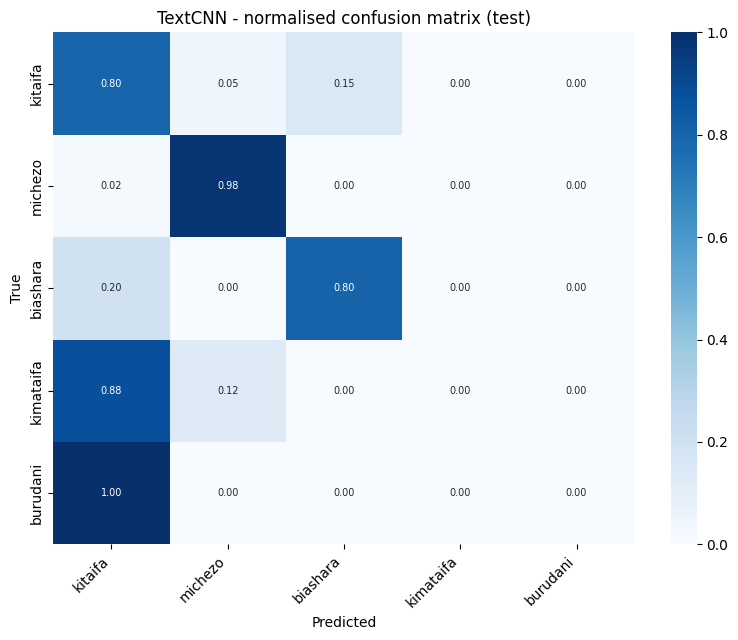

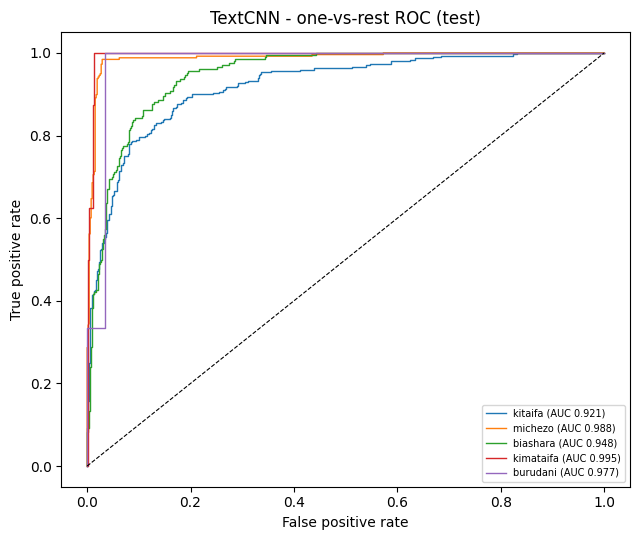

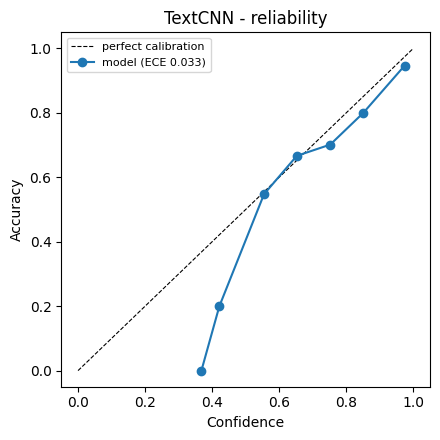

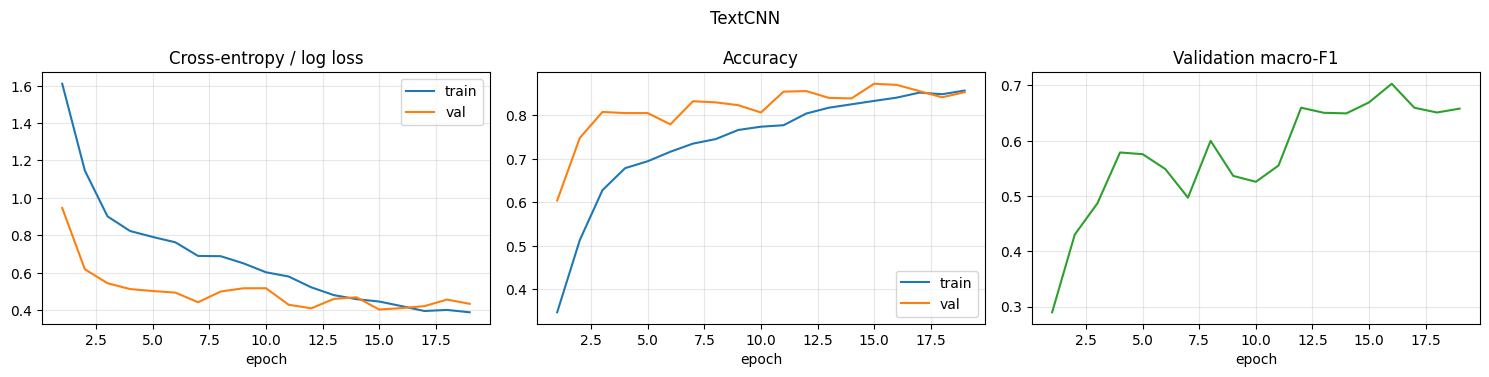

{
  "log_loss": 0.4254,
  "accuracy": 0.8473,
  "macro_f1": 0.511,
  "weighted_f1": 0.8412,
  "top2_accuracy": 0.9858,
  "ece": 0.0333,
  "roc_auc_ovr_macro": 0.9658,
  "log_loss_ci95": [
    0.3587077884822604,
    0.5006875505738758
  ],
  "accuracy_ci95": [
    0.8214747736093143,
    0.8732212160413971
  ],
  "macro_f1_ci95": [
    0.4961280814253275,
    0.5262606269088591
  ],
  "model": "TextCNN",
  "key": "textcnn",
  "selected_experiment": "CNN-01",
  "n_trainable_params": 3636229,
  "val_log_loss": 0.4034
}
Submission written to /content/swahili-news-sequential/submissions/textcnn.csv


In [7]:
s = seqs(best["exp"]["params"].get("max_len", C.MAX_WORDS))
model, proba_test, metrics = finalize(best, build_model, TokenDataset(s["te"], yte), yte, te.id.values, C.CLASSES,
                                      key="textcnn", display_name="TextCNN", collate_fn=pad_collate,
                                      zindi_ds=TokenDataset(s["z"]), zindi_df=zindi)

In [8]:
from src.utils import persist_outputs
persist_outputs()

Outputs copied to /content/drive/MyDrive/swahili-news/outputs


In [9]:
!cp "/content/drive/MyDrive/Colab Notebooks/Copy of 03_textcnn.ipynb" \
    /content/swahili-news-sequential/notebooks/01_eda.ipynb